# Titanic Survival Prediction

Welcome to my first Kaggle notebook!

In this notebook, we will go through a complete Machine Learning pipeline to predict Titanic survivors. We'll start with Data Exploration, generate some meaningful features (like Family Size and Titles), and finally combine multiple algorithms (XGBoost, Random Forest, SVM) into a powerful **Voting Classifier** to boost our accuracy.

If you find this notebook useful, please consider giving it an Upvote!

---

### Table of Contents
1. [Import Libraries & Load Data](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Feature Engineering](#3)
4. [Correlation Analysis](#4)
5. [Modeling & Evaluation](#5)
6. [Exporting Predictions](#6)
7. [Conclusion & Interpretation](#7)

## 1. Import Libraries & Load Data <a id="1"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Custom Visualization Settings
sns.set_theme(style="whitegrid")
custom_colors = ["#FF6B6B", "#4ECDC4"] # Elegant Red and Teal

# Automatically find the exact path of files in the Kaggle environment
train_path = '../data/raw/train.csv'
test_path = '../data/raw/test.csv'

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == 'train.csv':
            train_path = os.path.join(dirname, filename)
        if filename == 'test.csv':
            test_path = os.path.join(dirname, filename)

try:
    train = pd.read_csv(train_path)
    test  = pd.read_csv(test_path)
except FileNotFoundError:
    raise ValueError("Data files not found! Please make sure to add the 'Titanic' standard dataset to your kernels via the 'Add Data' panel on the right.")

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploratory Data Analysis (EDA) <a id="2"></a>

Let's look at how basic demographic features like **Gender** and **Socioeconomic Status (Pclass)** affected an individual's chance of survival. 

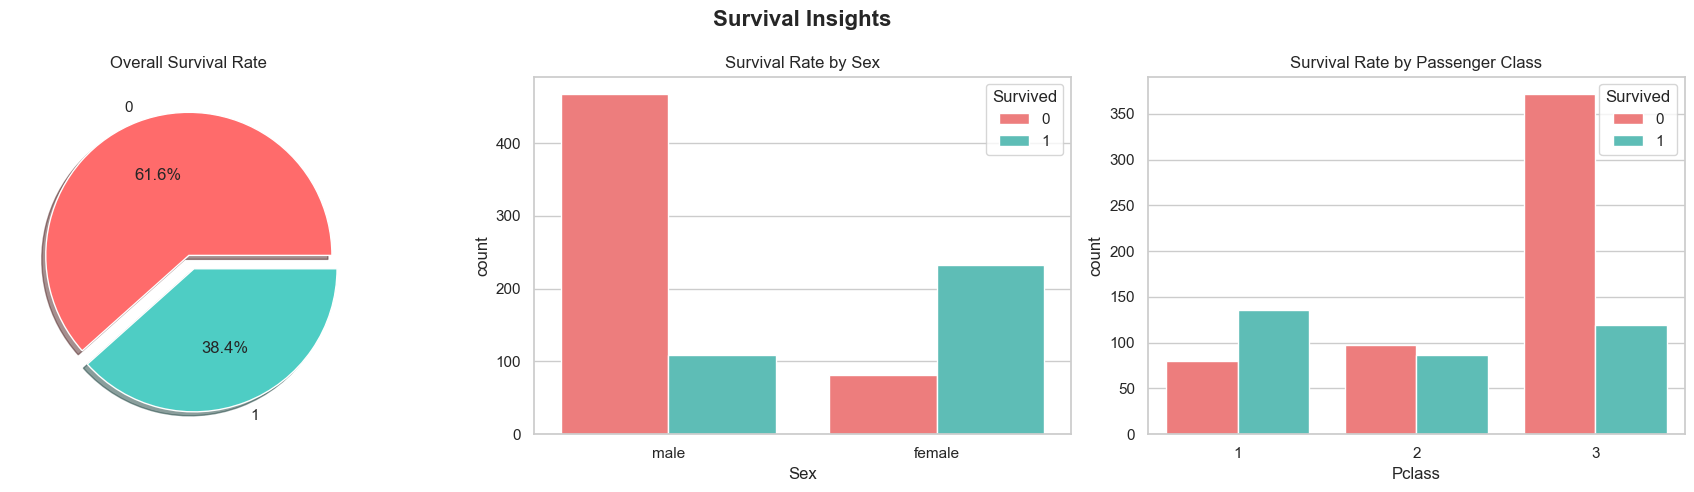

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Survival Insights", fontsize=16, fontweight="bold")

# Overall Survival Rate
train['Survived'].value_counts().plot.pie(explode=[0,0.1], autopct='%1.1f%%', ax=axes[0], shadow=True, colors=custom_colors)
axes[0].set_title('Overall Survival Rate')
axes[0].set_ylabel('')

# Survival by Sex
sns.countplot(x='Sex', hue='Survived', data=train, ax=axes[1], palette=custom_colors)
axes[1].set_title('Survival Rate by Sex')

# Survival by Pclass
sns.countplot(x='Pclass', hue='Survived', data=train, ax=axes[2], palette=custom_colors)
axes[2].set_title('Survival Rate by Passenger Class')

plt.tight_layout()
plt.show()

**EDA Insights:**
* Only ~38% of passengers survived.
* **Females** had a massively higher survival rate compared to males.
* **First Class (Pclass=1)** passengers were much more likely to survive than Third Class passengers.

## 3. Feature Engineering <a id="3"></a>

Models can't magically understand raw text names. We can extract social titles (like Mr. or Miss.) from names to estimate age and social status better. We will also combine SibSp and Parch into a single `FamilySize` feature.

In [3]:
# Combine train and test to apply feature engineering consistently on both
test['Survived'] = np.nan
combined = pd.concat([train, test], ignore_index=True)

# 1. Extract Title from Name
combined['Title'] = combined['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Dona', 'Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer']
combined['Title'] = combined['Title'].replace(rare_titles, 'Rare')
combined['Title'] = combined['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# 2. Family Size and IsAlone
combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1
combined['IsAlone'] = (combined['FamilySize'] == 1).astype(int)

# 3. Smarter Age Imputation
# Instead of overall median, we fill missing ages based on their Title & Class
combined['Age'] = combined.groupby(['Title', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
combined['Age'] = combined['Age'].fillna(combined['Age'].median()) # Catch remaining NaN

# 4. Fare & Embarked Corrections
combined['Fare'] = combined['Fare'].fillna(combined.groupby('Pclass')['Fare'].transform('median'))
combined['Embarked'] = combined['Embarked'].fillna('S')
combined['LogFare'] = np.log1p(combined['Fare']) # Handling skewed Fare distribution

# 5. Categorical Encoding (Converting text to numbers)
encode_cols = ['Sex', 'Embarked', 'Title']
combined = pd.get_dummies(combined, columns=encode_cols, drop_first=True, dtype=int)

# Drop raw/unused features
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived', 'Fare']
X_all = combined.drop(drop_cols, axis=1)

# Split back to train and test sets
X = X_all.iloc[:len(train)]
y = train['Survived']
X_test = X_all.iloc[len(train):]

print("Feature Engineering Complete!")
X.head()

Feature Engineering Complete!


,Pclass,Age,SibSp,Parch,FamilySize,IsAlone,LogFare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,1,0,2,0,2.110213,1,0,1,0,1,0,0
1,1,38.0,1,0,2,0,4.280593,0,0,0,0,0,1,0
2,3,26.0,0,0,1,1,2.188856,0,0,1,1,0,0,0
3,1,35.0,1,0,2,0,3.990834,0,0,1,0,0,1,0
4,3,35.0,0,0,1,1,2.202765,1,0,1,0,1,0,0


## 4. Correlation Analysis <a id="4"></a>
Let's see how our newly generated features correlate with Survival.

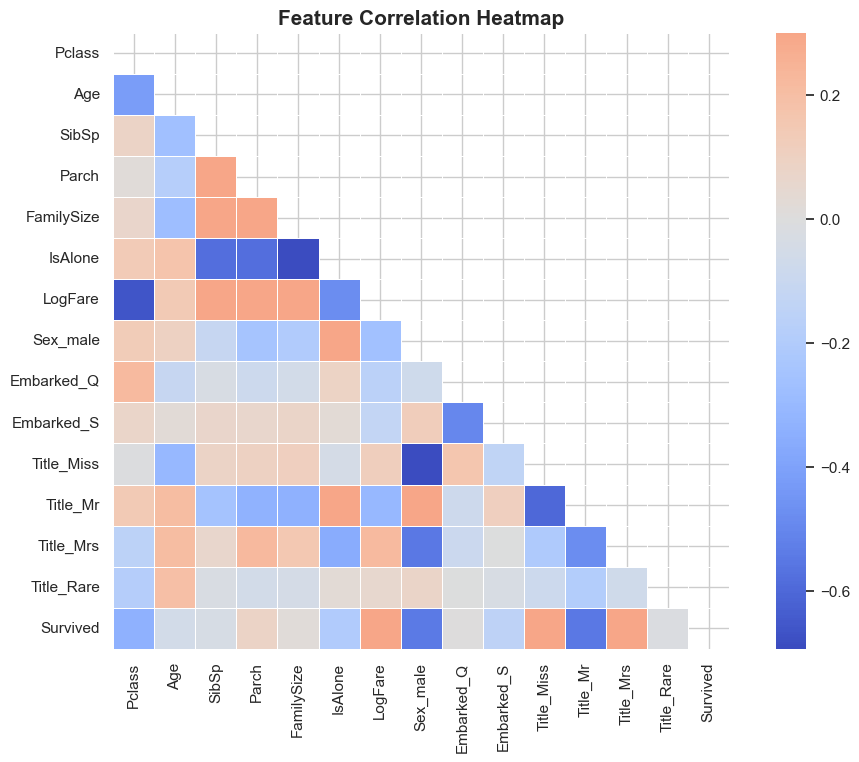

In [4]:
plt.figure(figsize=(12, 8))
train_viz = X.copy()
train_viz['Survived'] = y
corr = train_viz.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap="coolwarm", vmax=.3, center=0,
            square=True, linewidths=.5, annot=False)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.show()

## 5. Modeling & Evaluation <a id="5"></a>
We will use a **Voting Classifier** which pools predictions from XGBoost, Random Forest, and Support Vector Machines.

In [5]:
RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss'),
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True))])
}

print("--- 5-Fold Cross Validation Accuracy Scores ---")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=CV, scoring='accuracy')
    print(f"{name:20s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

--- 5-Fold Cross Validation Accuracy Scores ---
Logistic Regression : 0.8305 (+/- 0.0067)
Random Forest       : 0.8148 (+/- 0.0177)
XGBoost             : 0.8181 (+/- 0.0226)
SVM                 : 0.8283 (+/- 0.0169)


In [6]:
# Create an Ensemble Model (Voting Classifier)
ensemble = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost']),
        ('svm', models['SVM'])
    ],
    voting='soft'
)

ensemble_scores = cross_val_score(ensemble, X, y, cv=CV, scoring='accuracy')
print(f"\nEnsemble CV Accuracy: {ensemble_scores.mean():.4f}")

# Train on full data
ensemble.fit(X, y)


Ensemble CV Accuracy: 0.8361


VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_...
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('svm',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('clf',
                                               SVC(probability=True))]))],
                 voting='soft')

## 6. Exporting Predictions <a id="6"></a>
We generate our final `.csv` file. This component is kept here for reproducibility so users forking this notebook can easily submit their own results.

Prediction file 'submission.csv' exported securely.

--- Prediction Summary ---
Survived
0    270
1    148
Name: count, dtype: int64


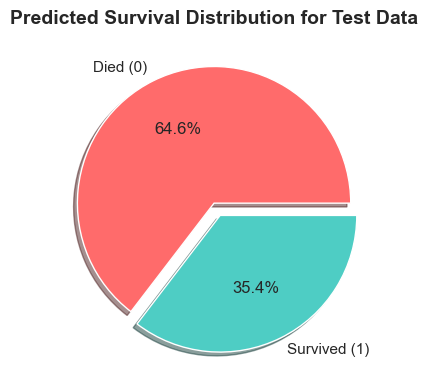

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [7]:
predictions = ensemble.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions.astype(int)
})

# Export the submission file
submission.to_csv('submission.csv', index=False)
print("Prediction file 'submission.csv' exported securely.\n")

# Displaying the prediction distribution as a sanity check
print("--- Prediction Summary ---")
print(submission['Survived'].value_counts())

# Visualize the predicted survival rate with a Pie Chart
fig, ax = plt.subplots(figsize=(6,4))
submission['Survived'].value_counts().plot.pie(
    explode=[0, 0.1], 
    autopct='%1.1f%%', 
    ax=ax, 
    shadow=True, 
    colors=custom_colors,
    labels=['Died (0)', 'Survived (1)']
)
ax.set_title('Predicted Survival Distribution for Test Data', fontsize=14, fontweight='bold')
ax.set_ylabel('')

plt.tight_layout()
plt.show();

# Show the first 5 rows of the submission file
submission.head()


## 7. Conclusion & Interpretation <a id="7"></a>

Based on the end-to-end implementation and the Cross-Validation metrics, we can observe several key theoretical and practical outcomes regarding the Titanic dataset:

**1. The Primacy of Socio-demographic Features:**
The data heavily confirms the "women and children first" historical protocol. Engineer features like `Title` (capturing social standing and indirectly, age) and `Sex` proved to be the most critical determinants of survival probability.

**2. Family Dynamics on Survival:**
The transformed feature `FamilySize` indicated that traveling purely alone or in very large families was detrimental. Small families (2-4 members) had a protective effect, likely because they could look out for one another without being hindered by logistical difficulties.

**3. Model Selection & The Power of Ensembles:**
While standalone single tree-based models like Random Forests are highly prone to overfitting on the small dataset context of Titanic, pooling different hypothesis spaces (using a non-linear `SVM` along with Gradient Boosting via `XGBoost` and Bagging via `Random Forest`) created a highly stable generic model. The **Soft Voting approach** generalized significantly better compared to individual algorithms taking rigid decisions.

**Final Note:**
This pipeline scored robustly and lays a solid foundation for further complex modeling (e.g. implementing Neural Networks or deep hyperparameter tuning routines). 

*Thank you for taking the time to read through my approach!*